In [1]:
import sys
from pathlib import Path
HOME = Path(r"D:\Workspace\Repository\skripsi\object-detection-engine")
DATA = HOME / "data"
MODELS  = HOME / "models"
sys.path.append(str(MODELS))

In [2]:
import nest_asyncio
nest_asyncio.apply()

from detector import OWLv2Detector

ONNX_MODEL_PATH = f"{MODELS}/owlv2/owlv2.onnx" 
PROCCESSOR_PATH = f"{MODELS}/owlv2"

In [3]:
detector = OWLv2Detector(
    model_path="models/owlv2/owlv2.onnx",
    processor_path="models/owlv2",
    device="cpu"
)

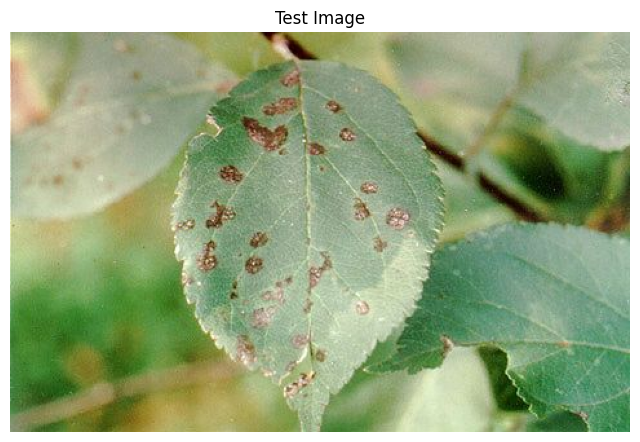

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_PATH = f"sample.jpg"
test_image = Image.open(IMAGE_PATH).convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(test_image)
plt.axis("off")
plt.title("Test Image")
plt.show()

In [5]:
labels = ["leaf with disease", "spots on leaf"]

In [6]:
from collections import Counter

detections = await detector.predict(
    image_input=IMAGE_PATH,
    labels=labels,
    threshold=0.3
)

label_counts = Counter(det['label'] for det in detections)

print("Detection Summary:")
for label, count in label_counts.items():
    print(f"{label}: {count} detection(s)")

print("\nDetailed Detections:")
for det in detections:
    box = det['box']
    print(f"{det['label']}: {det['score']:.3f} at [{box[0]:.1f}, {box[1]:.1f}, {box[2]:.1f}, {box[3]:.1f}]")

Detection Summary:
leaf with disease: 3 detection(s)
spots on leaf: 2 detection(s)

Detailed Detections:
leaf with disease: 0.518 at [0.0, 0.4, 181.2, 105.6]
spots on leaf: 0.303 at [192.8, 32.5, 223.1, 42.6]
spots on leaf: 0.405 at [161.6, 66.6, 181.3, 76.0]
leaf with disease: 0.877 at [116.8, 9.3, 348.5, 203.1]
leaf with disease: 0.412 at [252.7, 90.8, 477.8, 206.1]


In [7]:
detections

[{'box': [0.0, 0.44549107551574707, 181.19287490844727, 105.57257115840912],
  'score': 0.5179213285446167,
  'label': 'leaf with disease'},
 {'box': [192.77461051940918,
   32.54886955022812,
   223.1330394744873,
   42.59298413991928],
  'score': 0.3029676377773285,
  'label': 'spots on leaf'},
 {'box': [161.5982437133789,
   66.64531245827675,
   181.26245498657227,
   75.98128840327263],
  'score': 0.4049709141254425,
  'label': 'spots on leaf'},
 {'box': [116.76061391830444,
   9.318681061267853,
   348.51799964904785,
   203.0996584892273],
  'score': 0.876849889755249,
  'label': 'leaf with disease'},
 {'box': [252.7309799194336,
   90.84979325532913,
   477.7548408508301,
   206.145738363266],
  'score': 0.4123705327510834,
  'label': 'leaf with disease'}]

In [8]:
visualized = detector.visualize_detections(
    image_input=IMAGE_PATH,
    detections=detections,
    output_format='bytes'
)


In [9]:
with open('output.png', 'wb') as f:
    f.write(visualized)